# 1. Khai báo thư viện ảnh

In [30]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import numpy as np
import cv2
import matplotlib.pyplot as CaoMinhTri

# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu

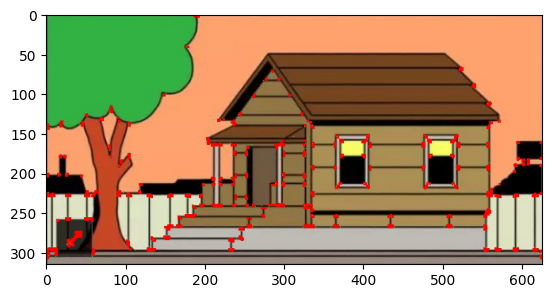

In [31]:
img = cv2.imread('house.png')        # Đọc file ảnh "house.png" bằng OpenCV và lưu vào biến img (dạng ma trận NumPy BGR)

CaoMinhTri.imshow(img[:, :, ::-1])   # Hiển thị ảnh bằng hàm imshow, đồng thời đảo thứ tự kênh màu từ BGR -> RGB

# 2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh.

In [32]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

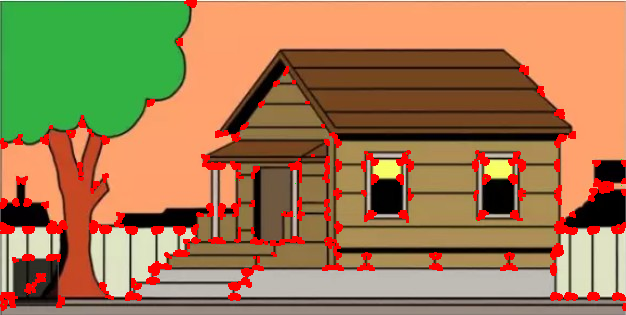

In [33]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)     # Chuyển ảnh màu (BGR) sang ảnh xám (Grayscale)

gray = np.float32(gray)                        # Chuyển kiểu dữ liệu của ảnh xám sang float32 (bắt buộc cho thuật toán Harris)

dst = cv.cornerHarris(gray, 2, 3, 0.04)        # Áp dụng thuật toán Harris Corner Detection
                                               # 2  : kích thước cửa sổ xét lân cận (blockSize)
                                               # 3  : kích thước Sobel dùng tính gradient
                                               # 0.04 : hệ số k trong công thức Harris

dst = cv.dilate(dst, None)                     # Phép giãn ảnh (dilation) để làm nổi bật các điểm góc

img[dst > 0.01 * dst.max()] = [0,0,255]        # Nếu giá trị Harris lớn hơn ngưỡng → đánh dấu pixel đó là góc
                                               # [0,0,255] là màu đỏ trong hệ BGR

cv2_imshow(img)                                # Hiển thị ảnh kết quả (các góc được đánh dấu màu đỏ)

# Corner with SubPixel Accuracy

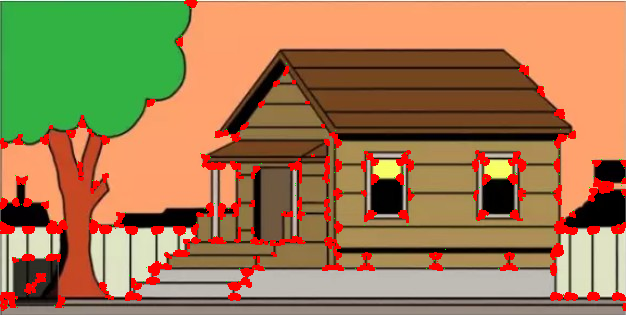

In [34]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)                 # Chuyển ảnh màu sang ảnh xám

gray = np.float32(gray)                                    # Chuyển kiểu dữ liệu sang float32 để dùng cho Harris
dst = cv.cornerHarris(gray, 2, 3, 0.04)                    # Phát hiện các điểm góc bằng thuật toán Harris
dst = cv.dilate(dst, None)                                 # Làm nổi bật các điểm góc

ret, dst = cv.threshold(dst, 0.01 * dst.max(), 255, 0)     # Lọc các điểm góc mạnh bằng ngưỡng
dst = np.uint8(dst)                                        # Chuyển kết quả về kiểu uint8

ret, labels, stats, centroids = cv.connectedComponentsWithStats(dst)    # Tìm các vùng liên thông và tính tâm của mỗi vùng

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.001)  # Điều kiện dừng cho thuật toán tinh chỉnh góc

corners = cv.cornerSubPix(gray, np.float32(centroids), (5,5), (-1,-1), criteria)  # Tinh chỉnh vị trí góc chính xác hơn

res = np.hstack((centroids, corners))                      # Ghép tọa độ tâm và tọa độ góc đã tinh chỉnh
res = res.astype(int)                                      # Chuyển tọa độ về số nguyên

img[res[:,1], res[:,0]] = [0,0,255]                        # Đánh dấu tâm góc ban đầu bằng màu đỏ
img[res[:,3], res[:,2]] = [0,255,0]                        # Đánh dấu góc sau khi tinh chỉnh bằng màu xanh

cv.imwrite('house.png', img)                               # Lưu ảnh kết quả ra file
cv2_imshow(img)                                            # Hiển thị ảnh kết quả

# 3. Sử dụng Band-pass filtering by Difference of Gaussians

In [35]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

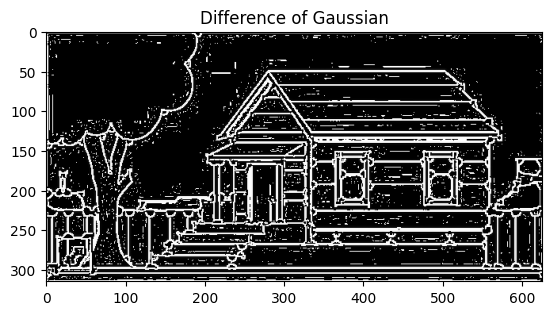

In [36]:
img = cv2.imread("house.png", 0)              # Đọc ảnh house.png ở chế độ ảnh xám

blur1 = cv2.GaussianBlur(img, (5,5), 1)       # Làm mờ ảnh bằng Gaussian với sigma = 1

blur2 = cv2.GaussianBlur(img, (5,5), 2)       # Làm mờ ảnh bằng Gaussian với sigma = 2

dog = blur1 - blur2                           # Lấy hiệu hai ảnh đã làm mờ để tạo Difference of Gaussian

CaoMinhTri.imshow(dog, cmap='gray')           # Hiển thị ảnh kết quả ở dạng thang xám

CaoMinhTri.title("Difference of Gaussian")    # Đặt tiêu đề cho hình hiển thị

CaoMinhTri.show()                             # Hiển thị cửa sổ ảnh

# 4. Kiểm tra ảnh qua Automatic Scale Selection

In [37]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

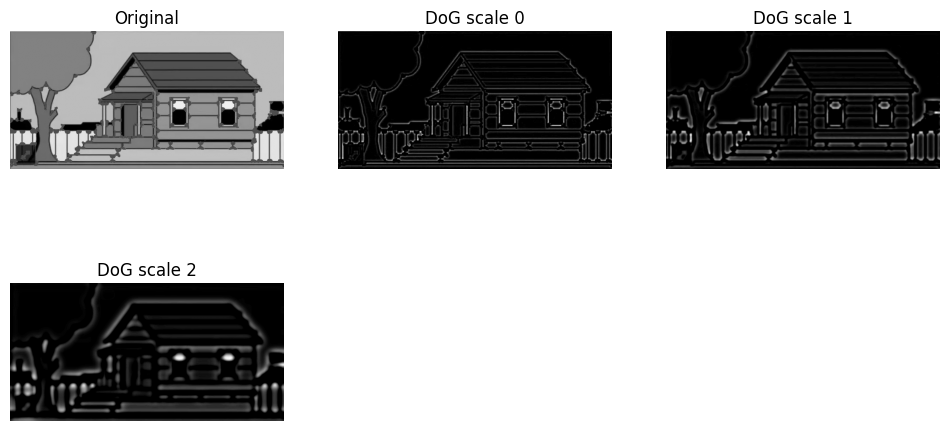

In [38]:
img = cv2.imread('house.png', 0)                     # Đọc ảnh house.png ở dạng ảnh xám

sigmas = [1, 2, 4, 8]                                # Danh sách các mức sigma để tạo nhiều mức làm mờ

gaussians = []                                       # Danh sách lưu các ảnh sau khi làm mờ Gaussian

for s in sigmas:                                     # Lặp qua từng giá trị sigma
    blur = cv2.GaussianBlur(img, (0,0), s)           # Làm mờ ảnh bằng Gaussian với sigma tương ứng
    gaussians.append(blur)                           # Lưu ảnh đã làm mờ vào danh sách

dogs = []                                            # Danh sách lưu kết quả Difference of Gaussian

for i in range(len(gaussians)-1):                    # Lặp qua các ảnh Gaussian để tính hiệu
    dog = cv2.subtract(gaussians[i], gaussians[i+1]) # Lấy hiệu giữa hai ảnh Gaussian liên tiếp
    dogs.append(dog)                                 # Lưu kết quả vào danh sách

CaoMinhTri.figure(figsize=(12,6))                    # Tạo cửa sổ hiển thị kích thước lớn hơn

CaoMinhTri.subplot(2,3,1)                            # Tạo ô hiển thị đầu tiên
CaoMinhTri.title("Original")                         # Tiêu đề ảnh gốc
CaoMinhTri.imshow(img, cmap='gray')                  # Hiển thị ảnh gốc ở dạng thang xám
CaoMinhTri.axis("off")                               # Ẩn trục tọa độ

for i in range(len(dogs)):                           # Lặp qua các ảnh DoG
    CaoMinhTri.subplot(2,3,i+2)                      # Tạo các ô hiển thị tiếp theo
    CaoMinhTri.title(f"DoG scale {i}")                # Đặt tiêu đề cho từng mức DoG
    CaoMinhTri.imshow(dogs[i], cmap='gray')          # Hiển thị ảnh DoG
    CaoMinhTri.axis("off")                           # Ẩn trục tọa độ

CaoMinhTri.show()                                    # Hiển thị toàn bộ kết quả

# 5. Kiểm tra ảnh qua Scale Invariant Detection

In [39]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import matplotlib.pyplot as CaoMinhTri

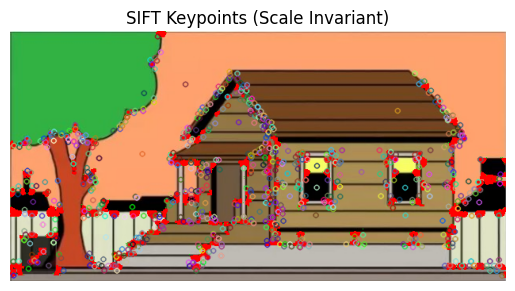

In [40]:
img = cv2.imread("house.png")                      # Đọc ảnh house.png

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)       # Chuyển ảnh màu sang ảnh xám

sift = cv2.SIFT_create()                           # Tạo bộ phát hiện đặc trưng SIFT

keypoints, descriptors = sift.detectAndCompute(gray, None)
                                                  # Phát hiện các điểm đặc trưng và tính vector mô tả

img_kp = cv2.drawKeypoints(img, keypoints, None)   # Vẽ các điểm đặc trưng lên ảnh

CaoMinhTri.imshow(img_kp[:,:,::-1])                # Hiển thị ảnh và đổi thứ tự kênh màu BGR sang RGB

CaoMinhTri.title("SIFT Keypoints (Scale Invariant)") # Đặt tiêu đề cho ảnh hiển thị

CaoMinhTri.axis("off")                             # Ẩn trục tọa độ

CaoMinhTri.show()                                  # Hiển thị ảnh

# 6. Kiểm tra ảnh qua Scale-space blob detector.

In [41]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

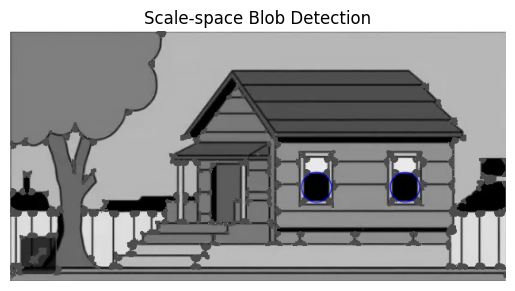

In [42]:
img = cv2.imread("house.png", 0)                     # Đọc ảnh house.png ở dạng ảnh xám

params = cv2.SimpleBlobDetector_Params()             # Tạo đối tượng tham số cho bộ phát hiện blob

params.filterByArea = True                           # Bật điều kiện lọc theo diện tích
params.minArea = 50                                  # Chỉ giữ các blob có diện tích lớn hơn hoặc bằng 50

detector = cv2.SimpleBlobDetector_create(params)     # Tạo bộ phát hiện blob với các tham số đã thiết lập

keypoints = detector.detect(img)                     # Phát hiện các blob trong ảnh

img_blob = cv2.drawKeypoints(                        # Vẽ các blob lên ảnh
    img,
    keypoints,
    None,
    (0,0,255),                                       # Màu đỏ để đánh dấu blob
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS       # Hiển thị blob với kích thước tương ứng
)

CaoMinhTri.imshow(img_blob, cmap='gray')             # Hiển thị ảnh kết quả ở dạng thang xám
CaoMinhTri.title("Scale-space Blob Detection")       # Đặt tiêu đề cho ảnh hiển thị
CaoMinhTri.axis("off")                               # Ẩn trục tọa độ
CaoMinhTri.show()                                    # Hiển thị ảnh

# 7. Thực hành với Bag-of-words detection

In [43]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

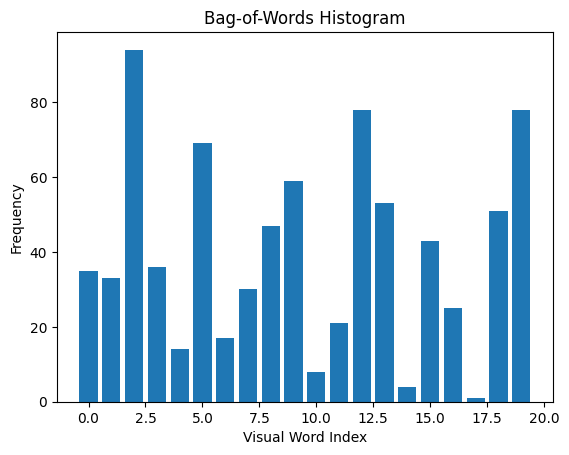

In [44]:
img = cv2.imread("house.png")                           # Đọc ảnh house.png

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)            # Chuyển ảnh màu sang ảnh xám

sift = cv2.SIFT_create()                                # Tạo bộ phát hiện đặc trưng SIFT

keypoints, descriptors = sift.detectAndCompute(gray, None)
                                                       # Phát hiện các điểm đặc trưng và tạo vector mô tả

k = 20                                                  # Số lượng cụm đặc trưng cần tạo

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
                                                       # Điều kiện dừng cho thuật toán phân cụm

_, labels, centers = cv2.kmeans(
    descriptors.astype(np.float32),                    # Chuyển descriptors sang kiểu float32
    k,                                                 # Số cụm cần chia
    None,                                              # Không dùng nhãn ban đầu
    criteria,                                          # Điều kiện dừng
    10,                                                # Số lần chạy lại thuật toán
    cv2.KMEANS_RANDOM_CENTERS                          # Khởi tạo tâm cụm ngẫu nhiên
)

histogram = np.bincount(labels.flatten(), minlength=k) # Tạo histogram biểu diễn số lượng đặc trưng trong mỗi cụm

CaoMinhTri.bar(range(k), histogram)                    # Vẽ biểu đồ cột của histogram

CaoMinhTri.title("Bag-of-Words Histogram")             # Đặt tiêu đề biểu đồ

CaoMinhTri.xlabel("Visual Word Index")                 # Nhãn trục ngang

CaoMinhTri.ylabel("Frequency")                         # Nhãn trục dọc

CaoMinhTri.show()                                      # Hiển thị biểu đồ

# 8. Ghép ảnh Image Panoramas

In [45]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

In [46]:
img1 = cv2.imread("vangogh1.png")                     # Đọc ảnh thứ nhất

img2 = cv2.imread("vangogh2.png")                     # Đọc ảnh thứ hai

stitcher = cv2.Stitcher_create()                      # Tạo đối tượng ghép ảnh

status, panorama = stitcher.stitch([img1, img2])     # Thực hiện ghép hai ảnh lại thành ảnh toàn cảnh

if status == cv2.Stitcher_OK:                         # Kiểm tra ghép ảnh có thành công hay không
    CaoMinhTri.imshow(panorama[:,:,::-1])             # Hiển thị ảnh kết quả và đổi kênh màu BGR sang RGB
    CaoMinhTri.title("Image Panorama")                # Đặt tiêu đề cho ảnh
    CaoMinhTri.axis("off")                            # Ẩn trục tọa độ
    CaoMinhTri.show()                                 # Hiển thị ảnh
else:
    print("Ghép ảnh thất bại")                        # Thông báo nếu quá trình ghép ảnh không thành công

Ghép ảnh thất bại


# 9. Ghép ảnh Automatic mosaicing

In [47]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

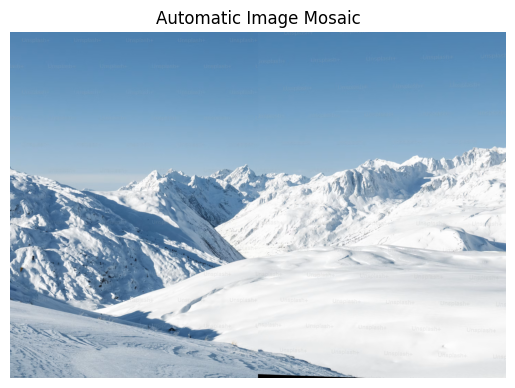

In [48]:
img1 = cv2.imread("snowy1.png")                      # Đọc ảnh thứ nhất
img2 = cv2.imread("snowy2.png")                      # Đọc ảnh thứ hai

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)       # Chuyển ảnh thứ nhất sang ảnh xám
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)       # Chuyển ảnh thứ hai sang ảnh xám

orb = cv2.ORB_create()                               # Tạo bộ phát hiện đặc trưng ORB

kp1, des1 = orb.detectAndCompute(gray1, None)        # Tìm các điểm đặc trưng và vector mô tả của ảnh 1
kp2, des2 = orb.detectAndCompute(gray2, None)        # Tìm các điểm đặc trưng và vector mô tả của ảnh 2

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)# Tạo bộ so khớp đặc trưng

matches = bf.match(des1, des2)                       # Tìm các cặp điểm đặc trưng tương ứng giữa hai ảnh
matches = sorted(matches, key=lambda x: x.distance)  # Sắp xếp các cặp điểm theo độ giống nhau

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)  # Lấy tọa độ các điểm tương ứng của ảnh 1
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)  # Lấy tọa độ các điểm tương ứng của ảnh 2

H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC) # Tính ma trận biến đổi hình học giữa hai ảnh

h, w = img1.shape[:2]                                # Lấy kích thước của ảnh thứ nhất
result = cv2.warpPerspective(img2, H, (w*2, h))      # Biến đổi ảnh thứ hai theo ma trận H
result[0:h, 0:w] = img1                              # Ghép ảnh thứ nhất vào kết quả

CaoMinhTri.imshow(result[:,:,::-1])                  # Hiển thị ảnh kết quả và đổi kênh màu BGR sang RGB
CaoMinhTri.title("Automatic Image Mosaic")           # Đặt tiêu đề cho ảnh
CaoMinhTri.axis("off")                               # Ẩn trục tọa độ
CaoMinhTri.show()                                    # Hiển thị ảnh

# 10. Sử dụng Wide base-line stereo

In [49]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import matplotlib.pyplot as CaoMinhTri

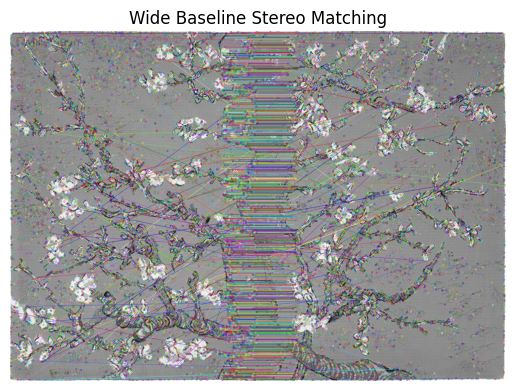

In [50]:
img1 = cv2.imread("vangogh1.png",0)                     # Đọc ảnh thứ nhất ở dạng ảnh xám
img2 = cv2.imread("vangogh2.png",0)                     # Đọc ảnh thứ hai ở dạng ảnh xám

sift = cv2.SIFT_create()                                # Tạo bộ phát hiện đặc trưng SIFT

kp1, des1 = sift.detectAndCompute(img1,None)            # Tìm các điểm đặc trưng và vector mô tả của ảnh 1
kp2, des2 = sift.detectAndCompute(img2,None)            # Tìm các điểm đặc trưng và vector mô tả của ảnh 2

bf = cv2.BFMatcher()                                    # Tạo bộ so khớp đặc trưng

matches = bf.knnMatch(des1, des2, k=2)                  # Tìm hai điểm đặc trưng gần nhất cho mỗi descriptor

good = []                                               # Danh sách lưu các cặp điểm khớp tốt

for m, n in matches:                                    # Duyệt qua các cặp điểm khớp
    if m.distance < 0.75 * n.distance:                  # Giữ lại các cặp điểm có độ tương đồng cao
        good.append([m])                                # Thêm cặp điểm khớp tốt vào danh sách

img_match = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good, None)
                                                        # Vẽ các cặp điểm tương ứng giữa hai ảnh

CaoMinhTri.imshow(img_match[:,:,::-1])                  # Hiển thị ảnh kết quả và đổi kênh màu BGR sang RGB
CaoMinhTri.title("Wide Baseline Stereo Matching")      # Đặt tiêu đề cho ảnh
CaoMinhTri.axis("off")                                  # Ẩn trục tọa độ
CaoMinhTri.show()                                       # Hiển thị ảnh

# 11. CBIR (content-based image retrieval)

In [51]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri

In [52]:
query = cv2.imread("snowy.png")                              # Đọc ảnh cần tìm kiếm

images = ["snowy1.png","snowy2.png","house.png"]              # Danh sách các ảnh trong cơ sở dữ liệu

query_hist = cv2.calcHist([query],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
                                                          # Tính histogram màu của ảnh cần tìm

query_hist = cv2.normalize(query_hist, query_hist).flatten() # Chuẩn hóa histogram và chuyển thành vector

scores = []                                                  # Danh sách lưu độ giống giữa các ảnh

for img_path in images:                                      # Duyệt qua từng ảnh trong cơ sở dữ liệu
    img = cv2.imread(img_path)                               # Đọc ảnh

    hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
                                                          # Tính histogram màu của ảnh

    hist = cv2.normalize(hist, hist).flatten()               # Chuẩn hóa histogram

    score = cv2.compareHist(query_hist, hist, cv2.HISTCMP_CORREL)
                                                          # So sánh độ giống giữa hai histogram

    scores.append((img_path, score))                         # Lưu tên ảnh và độ giống

scores = sorted(scores, key=lambda x: x[1], reverse=True)    # Sắp xếp ảnh theo độ giống giảm dần

print("Ảnh giống nhất:", scores)                             # In ra danh sách ảnh theo độ giống

Ảnh giống nhất: [('snowy2.png', 0.951574562126622), ('snowy1.png', 0.8610419373071838), ('house.png', -0.004704533086974131)]


# 12. Bag-of-word with SIFT + Histogram

In [53]:
# Import các thư viện cần thiết cho tác vụ xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as CaoMinhTri
from sklearn.cluster import KMeans

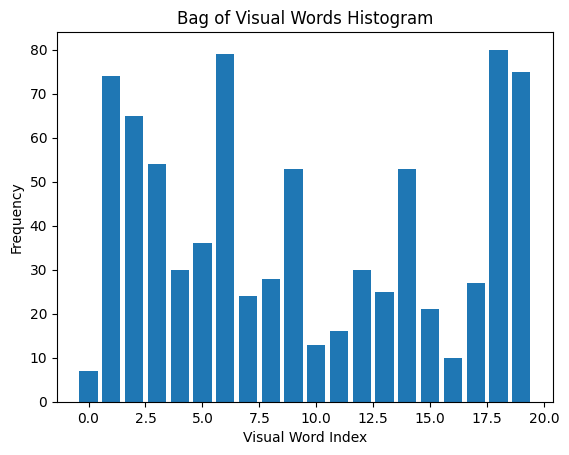

In [54]:
image_paths = ["house.png","snowy.png","vangogh.png"]     # Danh sách các ảnh trong bộ dữ liệu

sift = cv2.SIFT_create()                                  # Tạo bộ phát hiện đặc trưng SIFT

descriptors_list = []                                     # Danh sách lưu tất cả vector đặc trưng
image_descriptors = []                                    # Danh sách lưu vector đặc trưng theo từng ảnh

for path in image_paths:                                  # Duyệt qua từng ảnh
    img = cv2.imread(path,0)                              # Đọc ảnh ở dạng ảnh xám
    kp, des = sift.detectAndCompute(img,None)             # Tìm các điểm đặc trưng và vector mô tả

    if des is not None:                                   # Kiểm tra ảnh có phát hiện được đặc trưng hay không
        descriptors_list.append(des)                      # Lưu descriptor vào danh sách chung
        image_descriptors.append(des)                     # Lưu descriptor của từng ảnh

all_descriptors = np.vstack(descriptors_list)             # Gộp tất cả vector đặc trưng thành một ma trận

k = 20                                                    # Số cụm đặc trưng cần tạo

kmeans = KMeans(n_clusters=k)                             # Tạo mô hình phân cụm KMeans
kmeans.fit(all_descriptors)                               # Huấn luyện mô hình trên toàn bộ descriptor

histograms = []                                           # Danh sách lưu histogram đặc trưng của từng ảnh

for des in image_descriptors:                             # Duyệt qua descriptor của từng ảnh

    labels = kmeans.predict(des)                          # Xác định cụm mà mỗi descriptor thuộc về

    hist = np.zeros(k)                                    # Tạo histogram với k phần tử

    for label in labels:                                  # Đếm số descriptor thuộc từng cụm
        hist[label] += 1

    histograms.append(hist)                               # Lưu histogram của ảnh

CaoMinhTri.bar(range(k), histograms[0])                   # Vẽ histogram của ảnh đầu tiên

CaoMinhTri.title("Bag of Visual Words Histogram")         # Đặt tiêu đề biểu đồ

CaoMinhTri.xlabel("Visual Word Index")                    # Nhãn trục ngang

CaoMinhTri.ylabel("Frequency")                            # Nhãn trục dọc

CaoMinhTri.show()                                         # Hiển thị biểu đồ